# Figure 3 — SBS1 acceleration, covariates, and metastasis

All SBS1-vs-age analyses for the breast cohorts (INFORM, SCANB, PCAWG) plus the normal-tissue
reference and the Sanger primary→relapse metastasis pairs.

**GEL** is excluded from the exact-age scatter panels (1, 2, 4) — its export carries no
individual age. It **is** included in the covariate ridge (panel 3), where only 5-year
age-band midpoints are needed for the per-decade age term.

**Panels**
1. SBS1 acceleration — scaled SBS1 vs age (cohorts + normal-tissue fit)
2. Observed vs Expected SBS1 burden (tumour vs age-matched normal expectation)
3. Covariate ridge/OLS regression — subtype / grade / HRD status / age → scaled SBS1
4. Sanger metastasis — SBS1 accumulation between primary and relapse

**Data.** These analyses need per-sample **ploidy (G)**, **normal-tissue** exposures,
and **metastasis pairs** — none of which live in the combined
`HRDTimer_results_all_cohorts_v4.xlsx`. They are therefore read from the pre-computed
**supplement tables** listed at the top. (v4 holds the same clonal `scaled_SBS1` for the
QC-kept subset, but not these extra fields.)

## 0. Imports, style, and global paths

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import statsmodels.api as sm
from matplotlib.ticker import FuncFormatter
from scipy.stats import linregress
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.utils import resample

# ── Nature-like style: no top/right spines, thin (0.25) spines/ticks, embed fonts ──
def set_mpl_style():
    mpl.rcParams.update({
        "pdf.fonttype": 42, "ps.fonttype": 42,
        "font.family": "sans-serif", "font.size": 8,
        "text.color": "black", "axes.labelcolor": "black",
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.linewidth": 0.25, "axes.edgecolor": "black",
        "xtick.color": "black", "ytick.color": "black",
        "xtick.direction": "out", "ytick.direction": "out",
        "xtick.major.width": 0.25, "ytick.major.width": 0.25,
        "xtick.labelsize": 8, "ytick.labelsize": 8,
        "figure.dpi": 600,
    })
set_mpl_style()

# ── Global paths ──────────────────────────────────────────────────────────────
DATA = "../../data"
# Supplement tables
META_CSV        = f"{DATA}/metadata/pan_metadata_v10_SV_phenotypes.csv"          # subtype / grade / HRD origin
SUPP_DIR        = "../supplemental_tables_v2"                                     # published supplement tables
S3_SBS1_XLSX    = f"{SUPP_DIR}/SupTable10_SBS1_burden.xlsx"                         # clonal SBS1 (= Table S3)
S4_METS_XLSX    = f"{SUPP_DIR}/SupTable11_scaledSBS1_Age_Primary_Metastasis_SangerStudy.xlsx"  # Sanger (= Table S4)
S3_RENAME       = {"sample_id":"sample","age_at_diagnosis":"age","cohort":"Cohort","G_factor":"G","SBS1_mutations_total":"SBS1_total"}
S2_XLSX         = "../supplemental_tables_v2/SupTable8_HRDTimer_estimates.xlsx"   # HRDTimer estimates (GEL metadata + age bands)
S2_INV = {"sample_id": "sample", "subtype": "type", "is_WGD": "isWGD", "tumour_grade": "grade", "clinical_stage": "final_stage_main", "hrd_origin": "hrd.origin", "hrd_origin_with_methylation": "hrd.origin.with.meth", "HRD_genotype": "genotype", "CHORD_genotype": "chord.genotype", "TP53_mutated": "isTp53Mut", "PALB2_mutated": "isPALB2Mut", "HRDetect_score": "HRDetect", "is_HRD": "HRDetect.isHRD", "T_stage": "T_STAGE", "tumour_size_mm": "tum.size.mm", "age_band_label": "age_band", "BRCA1_monoallelic": "isBRCA1Monoallelic", "BRCA1_biallelic": "isBRCA1Biallelic", "BRCA2_monoallelic": "isBRCA2Monoallelic", "BRCA2_biallelic": "isBRCA2Biallelic", "BRCA1_promoter_methylation_class": "BRCA1_PromMetClass", "RAD51C_promoter_methylation_class": "RAD51C_PromMetClass", "HRDTime_molecular": "HRDTime", "HRDTime_molecular_ci_lo": "HRDTime_ci_lo", "HRDTime_molecular_ci_hi": "HRDTime_ci_hi", "HRDTime_molecular_IQR_lo": "HRDTime_ci_IQR_lo", "HRDTime_molecular_IQR_hi": "HRDTime_ci_IQR_hi", "WGDTime_molecular": "WGDTime", "WGDTime_molecular_ci_lo": "WGDTime_ci_lo", "WGDTime_molecular_ci_hi": "WGDTime_ci_hi", "WGDTime_molecular_IQR_lo": "WGDTime_ci_IQR_lo", "WGDTime_molecular_IQR_hi": "WGDTime_ci_IQR_hi", "HRD_duration_median_yrs": "HRD_Duration_median", "HRD_duration_ci05_yrs": "HRD_Duration_ci05", "HRD_duration_ci95_yrs": "HRD_Duration_ci95", "TS_duration_median_yrs": "TS_Duration_median", "TS_duration_ci05_yrs": "TS_Duration_ci05", "TS_duration_ci95_yrs": "TS_Duration_ci95", "HRD_onset_age_median": "HRD_crossing_age_median", "HRD_onset_age_ci05": "HRD_crossing_age_ci05", "HRD_onset_age_ci95": "HRD_crossing_age_ci95", "TS_onset_age_median": "TS_crossing_age_median", "TS_onset_age_ci05": "TS_crossing_age_ci05", "TS_onset_age_ci95": "TS_crossing_age_ci95"}
OUT_DIR         = "../output/Fig3_SBS1_acceleration"
os.makedirs(OUT_DIR, exist_ok=True)

COHORT_COLORS = {"INFORM": "#DFCC94", "SCANB": "#93A55D", "PCAWG": "#0F4722"}

## 1. How the SBS1-vs-age tables were generated (run once — not executed here)

Concise reference for reproducing the supplement tables for all cohorts.

In [2]:
# ── Per-cohort SBS1 exposures vs age (PCAWG / SCANB / INFORM) ──────────────────
# from hrdtimer import utils as HRDTimerUtils
# for COHORT in ["PCAWG", "SCANB", "INFORM"]:
#     sbs1_age = HRDTimerUtils.plot_sbs1_vs_age(
#         vcf_folder_path=f".../HRDTimer_PreProcess/{COHORT}/Breast/all_mut", cohort=COHORT)
# pd.concat([...]).to_csv(...)   # clonal SBS1 vs age -> Table S3 (SBS1 Burden)
#
# ── Normal-tissue and Sanger-metastasis exposures ─────────────────────────────
# Refit each SBS96 matrix to the COSMIC v3.2 Breast catalog with
# SigProfilerAssignment / MUSICAL, scale SBS1 by (2 * 3000) or (ploidy * 3000),
# then save the normal-tissue (Table S3 sheet) and Sanger metastasis (Table S4) supplements.
pass

## 2. Load supplement tables

In [3]:
# clonal SBS1 vs age (used for the acceleration scatter + observed/expected)
SBS1_acceleration_df = pd.read_excel(S3_SBS1_XLSX, sheet_name="SBS1 Burden").rename(columns=S3_RENAME)

# normal-tissue reference (keep non-driver samples for the fit)
NormalTissueExposures = pd.read_excel(S3_SBS1_XLSX, sheet_name="Normal Tissue Reference")
if "driver" in NormalTissueExposures.columns:
    NormalTissueExposures = NormalTissueExposures[NormalTissueExposures["driver"].isna()]

print("cohort samples:", SBS1_acceleration_df["Cohort"].value_counts().to_dict())
print("normal-tissue samples:", len(NormalTissueExposures))

cohort samples: {'PCAWG': 104, 'SCANB': 49, 'INFORM': 8}
normal-tissue samples: 29


## 3. Panel 1 — SBS1 acceleration vs age (no GEL)

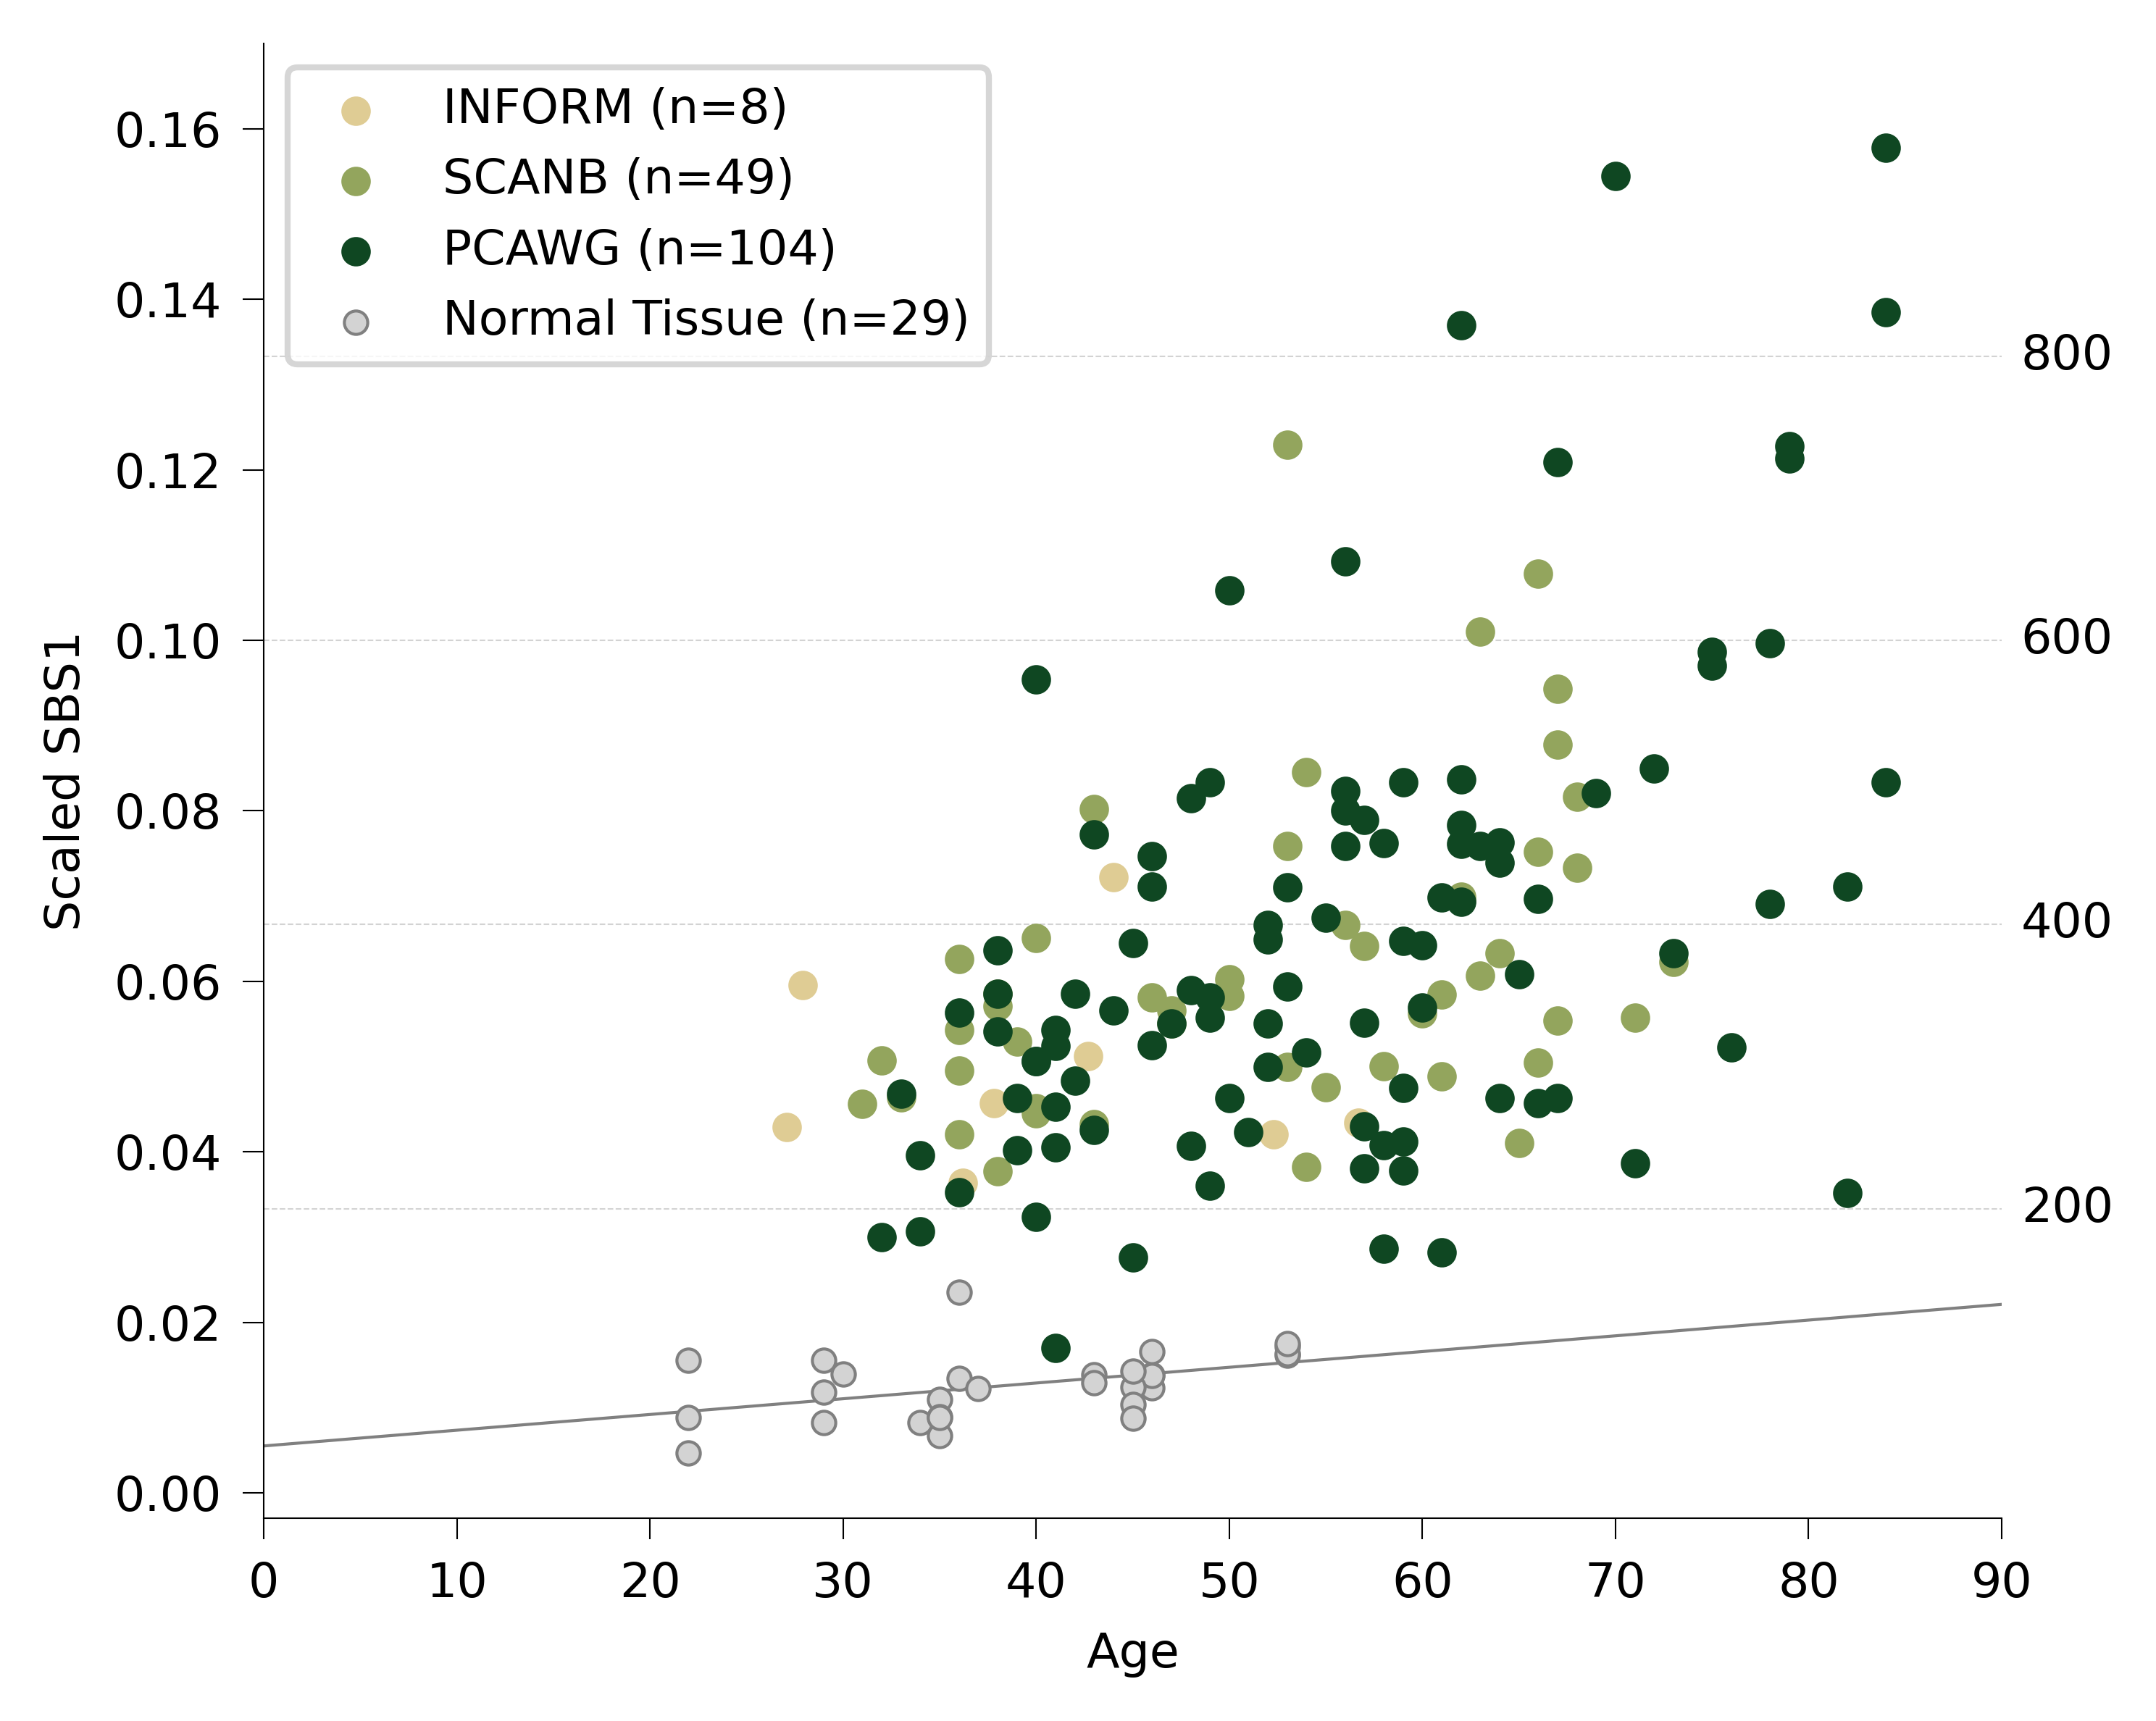

In [4]:
set_mpl_style()

x_nt = NormalTissueExposures["age"]
y_nt = NormalTissueExposures["scaled_SBS1"]
slope, intercept, *_ = linregress(x_nt, y_nt)
x_fit = np.linspace(0, 90, 100)
y_fit = slope * x_fit + intercept

fig, ax = plt.subplots(figsize=(5, 4))
for cohort, color in COHORT_COLORS.items():
    d = SBS1_acceleration_df[SBS1_acceleration_df["Cohort"] == cohort]
    ax.scatter(d["age"], d["scaled_SBS1"], label=f"{cohort} (n={len(d)})", color=color, s=15)

ax.plot(x_fit, y_fit, "-", color="grey", linewidth=0.5)
ax.scatter(x_nt, y_nt, color="lightgrey", label=f"Normal Tissue (n={len(x_nt)})",
           s=15, edgecolors="grey", linewidths=0.5, zorder=5)

ax.set_xlabel("Age"); ax.set_ylabel("Scaled SBS1")
ax.set_xlim(0, 90); ax.set_ylim(-0.003, 0.17)

# diploid-genome burden reference lines (value / 6000 = scaled)
for val in [200, 400, 600, 800]:
    ax.axhline(val / 6000, linestyle="--", color="lightgrey", linewidth=0.25, zorder=0)
    ax.text(91, val / 6000, f"{val}", va="center", ha="left", fontsize=8)

ax.legend(loc="upper left", fontsize=8)
for sp in ax.spines.values(): sp.set_linewidth(0.25)
ax.tick_params(width=0.25)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/SBS1_Acceleration_noGEL.pdf", format="pdf", bbox_inches="tight")
plt.show()

## 4. Panel 2 — Observed vs Expected SBS1 burden

Expected SBS1 accumulation rate (per diploid genome / decade≈): 1.1071761765637707


/tmp/ipykernel_1001512/2122848890.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([obs, exp], labels=["Observed\n(Tumour)", "Expected\n(Normal)"],


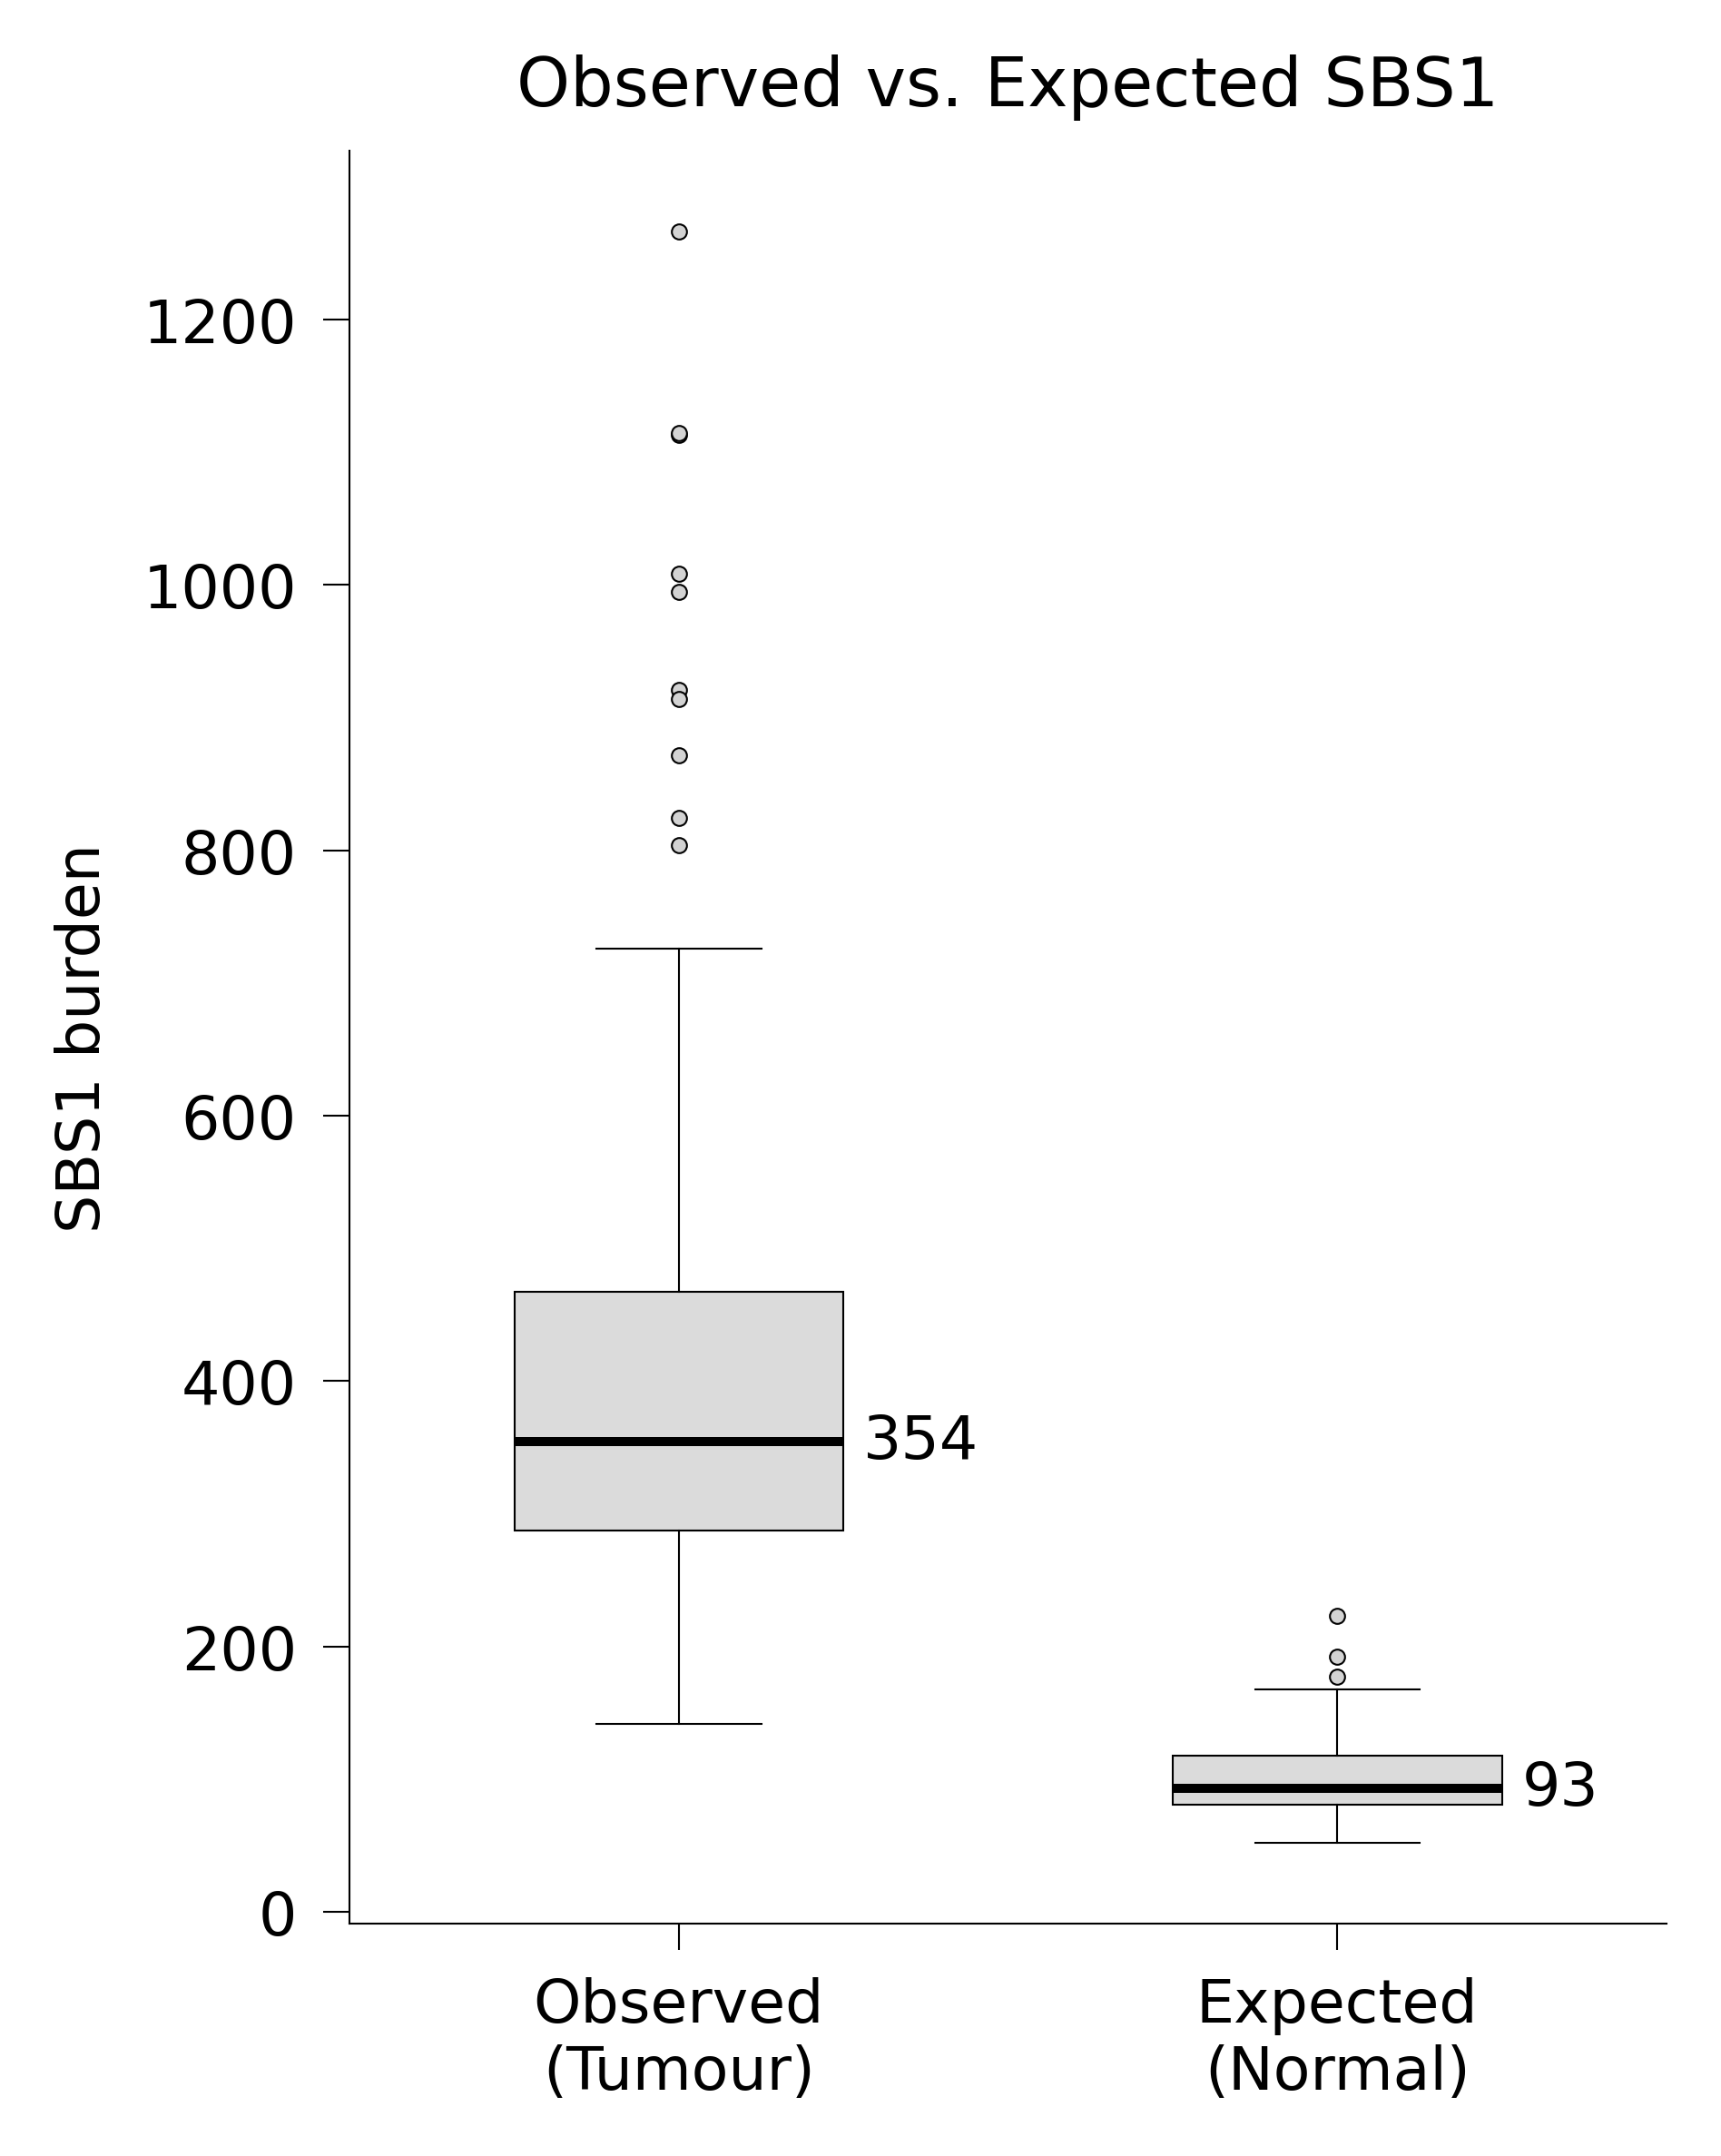

In [5]:
set_mpl_style()

# normal-tissue fit gives the age-matched expectation
slope, intercept, *_ = linregress(NormalTissueExposures["age"], NormalTissueExposures["scaled_SBS1"])
print("Expected SBS1 accumulation rate (per diploid genome / decade≈):", slope * 2 * 3000)

df = SBS1_acceleration_df.copy()
df["SBS1_patient"] = df["scaled_SBS1"] * 3000 * df["G"]                      # observed (tumour)
df["SBS1_normal"]  = (slope * df["age"] + intercept) * df["G"] * 3000        # expected (age-matched normal)
obs = df["SBS1_patient"].dropna()
exp = df["SBS1_normal"].dropna()
median_obs, median_exp = np.median(obs), np.median(exp)

fig, ax = plt.subplots(figsize=(3.2, 4))
bp = ax.boxplot([obs, exp], labels=["Observed\n(Tumour)", "Expected\n(Normal)"],
                patch_artist=True, widths=0.5,
                boxprops=dict(facecolor="#dbdbdb", edgecolor="black", linewidth=0.25),
                whiskerprops=dict(color="black", linewidth=0.25),
                capprops=dict(color="black", linewidth=0.25),
                medianprops=dict(color="black", linewidth=1.2),
                flierprops=dict(marker="o", markersize=2, markerfacecolor="lightgrey",
                                markeredgecolor="k", markeredgewidth=0.25))
ax.text(1.28, median_obs, f"{median_obs:.0f}", ha="left", va="center", fontsize=8)
ax.text(2.28, median_exp, f"{median_exp:.0f}", ha="left", va="center", fontsize=8)
ax.set_ylabel("SBS1 burden")
ax.set_title("Observed vs. Expected SBS1", fontsize=9)
for sp in ax.spines.values(): sp.set_linewidth(0.25)
ax.tick_params(width=0.25)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/SBS1_Observed_vs_Expected.pdf", format="pdf", bbox_inches="tight")
plt.show()

## 5. Panel 3 — Covariate ridge / OLS regression (incl. GEL via age bands)

Clonal SBS1 vs IHC subtype, grade, HRD status, and age. GEL included using age-band midpoints.

In [6]:
# ── PCAWG / SCANB / INFORM: clonal SBS1 + sample metadata ─────────────────────
acc_clonal = pd.read_excel(S3_SBS1_XLSX, sheet_name="SBS1 Burden").rename(columns=S3_RENAME)
meta = pd.read_csv(META_CSV)
meta_dedup = (meta[["sample", "genotype", "type", "grade", "hrd.origin.with.meth", "SV_phenotype2"]]
              .drop_duplicates(subset="sample"))

def normalise_grade(g):
    if pd.isna(g): return g
    g = str(g).strip()
    if g.startswith("G"): return g
    try: return f"G{int(float(g))}"
    except ValueError: return g

subtype_map = {"TN": "TNBC", "TNBC": "TNBC", "ER+": "ER+", "ER+HER2-": "ER+",
               "HER2": "HER2+", "HER2+": "HER2+", "other/unknown": "unknown"}

non_gel = (acc_clonal[["sample", "age", "scaled_SBS1", "Cohort"]].copy()
    .rename(columns={"age": "age_sampling"})
    .merge(meta_dedup, on="sample", how="left")
    .rename(columns={"type": "IHC_subtype", "hrd.origin.with.meth": "origin",
                     "SV_phenotype2": "BRCA_pheno", "genotype": "Gene_symbol"})
    .drop(columns=["sample"]))

# ── GEL from the combined workbook (v4): age = 5-year age-band midpoint ────────
# GEL has no exact age, but the ridge only needs a per-decade term, so band
# midpoints are sufficient -> GEL is included here (but not in the age scatters).
def band_mid(b):
    if pd.isna(b): return np.nan
    lo, hi = b.strip("[)").split(","); return (int(lo) + int(hi)) / 2

v4 = pd.read_excel(S2_XLSX, sheet_name="HRDTimer Estimates").rename(columns=S2_INV)
gel = v4[v4["cohort"] == "GEL"].copy()
gel_simple = (gel.assign(age_sampling=gel["age_band"].map(band_mid), Cohort="GEL")
    .rename(columns={"type": "IHC_subtype", "hrd.origin.with.meth": "origin",
                     "SV_phenotype2": "BRCA_pheno", "genotype": "Gene_symbol"}))

common = ["age_sampling", "scaled_SBS1", "Cohort", "IHC_subtype", "BRCA_pheno", "grade", "origin", "Gene_symbol"]
unified_df = pd.concat([non_gel[common], gel_simple[common]], ignore_index=True)

unified_df["grade"] = unified_df["grade"].apply(normalise_grade)
unified_df["IHC_subtype"] = unified_df["IHC_subtype"].map(
    lambda x: subtype_map.get(str(x).strip(), x) if pd.notna(x) else x).fillna("unknown")
unified_df["origin"] = unified_df["origin"].apply(lambda x: x.strip().lower() if isinstance(x, str) else x)
print(f"unified_df (incl. GEL): {unified_df.shape}")
print(unified_df["Cohort"].value_counts().to_dict())

unified_df (incl. GEL): (217, 8)
{'PCAWG': 104, 'GEL': 56, 'SCANB': 49, 'INFORM': 8}


n = 217 | HRD_status: {'HRD': 147, 'nonHRD': 70}
Ridge alpha=19.307  R2=0.223  n=217


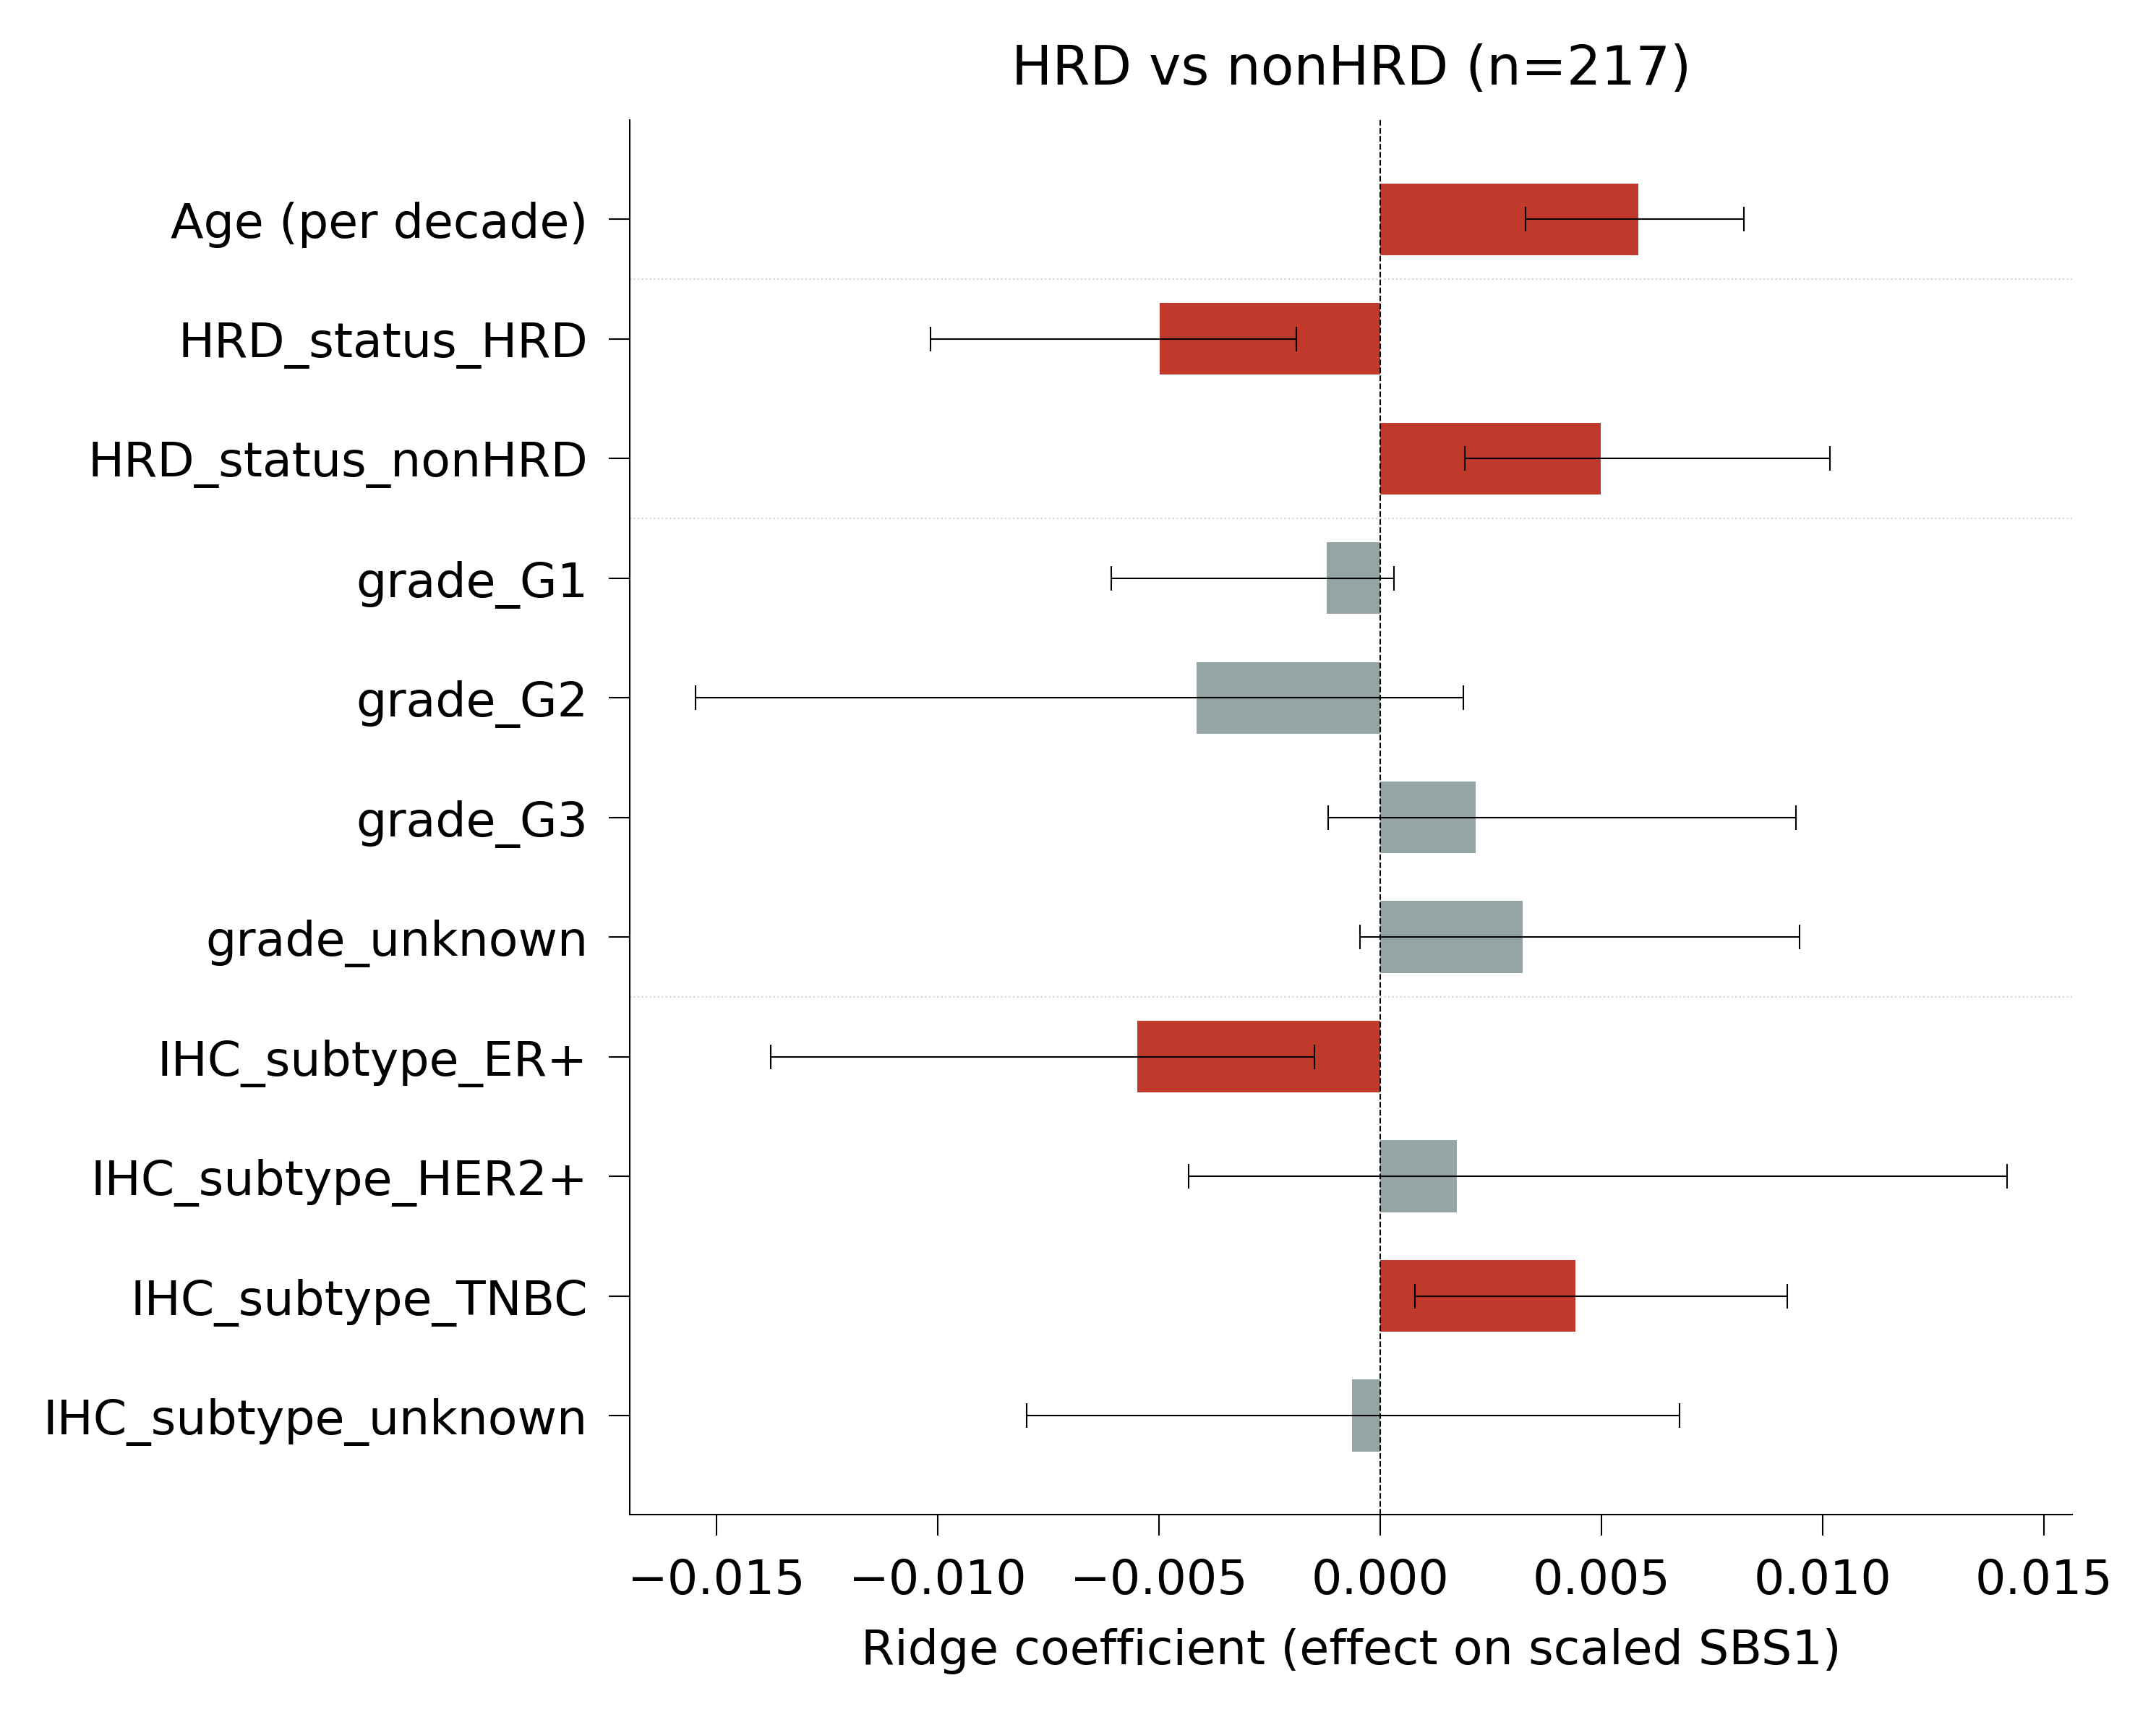

In [7]:
CAT_COLS, NUM_COLS, NONHRD_LABELS = ["IHC_subtype", "grade", "HRD_status"], ["age_sampling"], {"nonhrd"}

reg_df = (
    unified_df[["scaled_SBS1", "Cohort", "IHC_subtype", "grade", "origin", "age_sampling"]].copy()
    .assign(HRD_status=lambda d: np.where(d["origin"].isin(NONHRD_LABELS), "nonHRD", "HRD"))
    .assign(**{c: lambda d, c=c: d[c].fillna("unknown") for c in ["IHC_subtype", "grade"]})
    .assign(age_sampling=lambda d: d["age_sampling"].fillna(d["age_sampling"].median()) / 10)
    .dropna(subset=["scaled_SBS1"])
)
print(f"n = {len(reg_df)} | HRD_status: {reg_df['HRD_status'].value_counts().to_dict()}")

# ── Ridge with bootstrap 95% CIs ─────────────────────────────────────────────
pre = ColumnTransformer([
    ("cat", OneHotEncoder(drop=None, sparse_output=False,
                          categories=[sorted(reg_df[c].unique()) for c in CAT_COLS]), CAT_COLS),
    ("num", "passthrough", NUM_COLS)])
X = pre.fit_transform(reg_df[CAT_COLS + NUM_COLS]); y = reg_df["scaled_SBS1"].values
fn = pre.named_transformers_["cat"].get_feature_names_out(CAT_COLS).tolist() + ["Age (per decade)"]
fdf = pd.DataFrame(X, columns=fn)
ridge = RidgeCV(alphas=np.logspace(-3, 3, 50)).fit(fdf, y); r2 = ridge.score(fdf, y)
print(f"Ridge alpha={ridge.alpha_:.3f}  R2={r2:.3f}  n={len(y)}")
rng = np.random.default_rng(1)
boots = np.array([RidgeCV(alphas=np.logspace(-3, 3, 20))
                  .fit(*resample(fdf.values, y, random_state=int(rng.integers(1e9)))).coef_ for _ in range(500)])
boots_df = pd.DataFrame(boots, columns=fn)
coef_df = pd.DataFrame({"feature": fn, "coef": ridge.coef_,
                        "lo": np.percentile(boots, 2.5, axis=0), "hi": np.percentile(boots, 97.5, axis=0)})
coef_df["sig"] = (coef_df["lo"] > 0) | (coef_df["hi"] < 0)

group_order = [("Age", ["Age (per decade)"]),
               ("HRD", [f for f in fn if f.startswith("HRD_status_")]),
               ("Grade", [f for f in fn if f.startswith("grade_")]),
               ("IHC", [f for f in fn if f.startswith("IHC_subtype_")])]
ordered = [f for _, fs in group_order for f in fs]
coef_df = coef_df.set_index("feature").loc[ordered].reset_index()

set_mpl_style()
fig, ax = plt.subplots(figsize=(5, max(4, 0.35 * len(coef_df))))
y_pos = np.arange(len(coef_df))[::-1]
ax.barh(y_pos, coef_df["coef"], xerr=[coef_df["coef"] - coef_df["lo"], coef_df["hi"] - coef_df["coef"]],
        color=["#c0392b" if s else "#95a5a6" for s in coef_df["sig"]], height=0.6,
        error_kw=dict(lw=0.25, capsize=2, capthick=0.25, ecolor="black"))
ax.set_yticks(y_pos); ax.set_yticklabels(coef_df["feature"])
ax.axvline(0, color="black", lw=0.25, ls="--")
b = 0
for _, fs in group_order[:-1]:
    b += len(fs); ax.axhline(len(coef_df) - b - 0.5, color="lightgrey", lw=0.25, ls=":", zorder=0)
ax.set_xlabel("Ridge coefficient (effect on scaled SBS1)", fontsize=8)
ax.set_title(f"HRD vs nonHRD (n={len(y)})", fontsize=9)
for sp in ax.spines.values(): sp.set_linewidth(0.25)
ax.tick_params(width=0.25, labelsize=8)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/SBS1_RidgeCoef.pdf", format="pdf", bbox_inches="tight")
plt.show()

### OLS effect sizes, p-values, and key contrasts

In [8]:
ols_df = reg_df[["scaled_SBS1", "IHC_subtype", "grade", "HRD_status", "age_sampling"]].copy()
ols_df["IHC_subtype"] = pd.Categorical(ols_df["IHC_subtype"], categories=["ER+", "HER2+", "TNBC", "unknown"])
ols_df["grade"]       = pd.Categorical(ols_df["grade"], categories=["G2", "G1", "G3", "unknown"])
ols_df["HRD_status"]  = pd.Categorical(ols_df["HRD_status"], categories=["HRD", "nonHRD"])
X_ols = sm.add_constant(pd.get_dummies(
    ols_df[["IHC_subtype", "grade", "HRD_status", "age_sampling"]], drop_first=True).astype(float))
ols = sm.OLS(ols_df["scaled_SBS1"].values, X_ols).fit()

med_total_muts = (acc_clonal["G"] * 3000).median()
pval_keys = {"Age per decade": "age_sampling", "Grade G3 vs G2": "grade_G3",
             "TNBC vs ER+": "IHC_subtype_TNBC", "nonHRD vs HRD": "HRD_status_nonHRD"}
contrasts = {"Age per decade": ("Age (per decade)", None), "Grade G3 vs G2": ("grade_G3", "grade_G2"),
             "TNBC vs ER+": ("IHC_subtype_TNBC", "IHC_subtype_ER+"),
             "nonHRD vs HRD": ("HRD_status_nonHRD", "HRD_status_HRD")}
rows = []
for label, (a, bb) in contrasts.items():
    coef_ridge = ridge.coef_[fn.index(a)] - (ridge.coef_[fn.index(bb)] if bb else 0)
    boot_vals = boots_df[a] - (boots_df[bb] if bb else 0)
    lo, hi = np.percentile(boot_vals, [2.5, 97.5])
    rows.append({"Contrast": label, "Ridge coef": round(coef_ridge, 5),
                 "Ridge CI lo": round(lo, 5), "Ridge CI hi": round(hi, 5),
                 "Sig": bool((lo > 0) | (hi < 0)), "OLS coef": round(ols.params[pval_keys[label]], 5),
                 "~muts (OLS)": int(round(ols.params[pval_keys[label]] * med_total_muts)),
                 "OLS p": ols.pvalues[pval_keys[label]]})
summary = pd.DataFrame(rows)
print(f"n={len(y)}, Ridge alpha={ridge.alpha_:.3f}, R2={r2:.3f} | OLS R2={ols.rsquared:.3f}")
pd.set_option("display.float_format", "{:.5g}".format)
print(summary.to_string(index=False))

n=217, Ridge alpha=19.307, R2=0.223 | OLS R2=0.235
      Contrast  Ridge coef  Ridge CI lo  Ridge CI hi   Sig  OLS coef  ~muts (OLS)      OLS p
Age per decade     0.00583      0.00328      0.00822  True   0.00597           37 1.4155e-07
Grade G3 vs G2     0.00632       -0.002      0.02348 False    0.0128           80   0.045729
   TNBC vs ER+     0.00989      0.00461      0.01794  True   0.01289           80 0.00058111
 nonHRD vs HRD     0.00996      0.00381      0.02032  True   0.01405           87 0.00036689


## 6. Panel 4 — Sanger metastasis: SBS1 accumulation (primary → relapse)

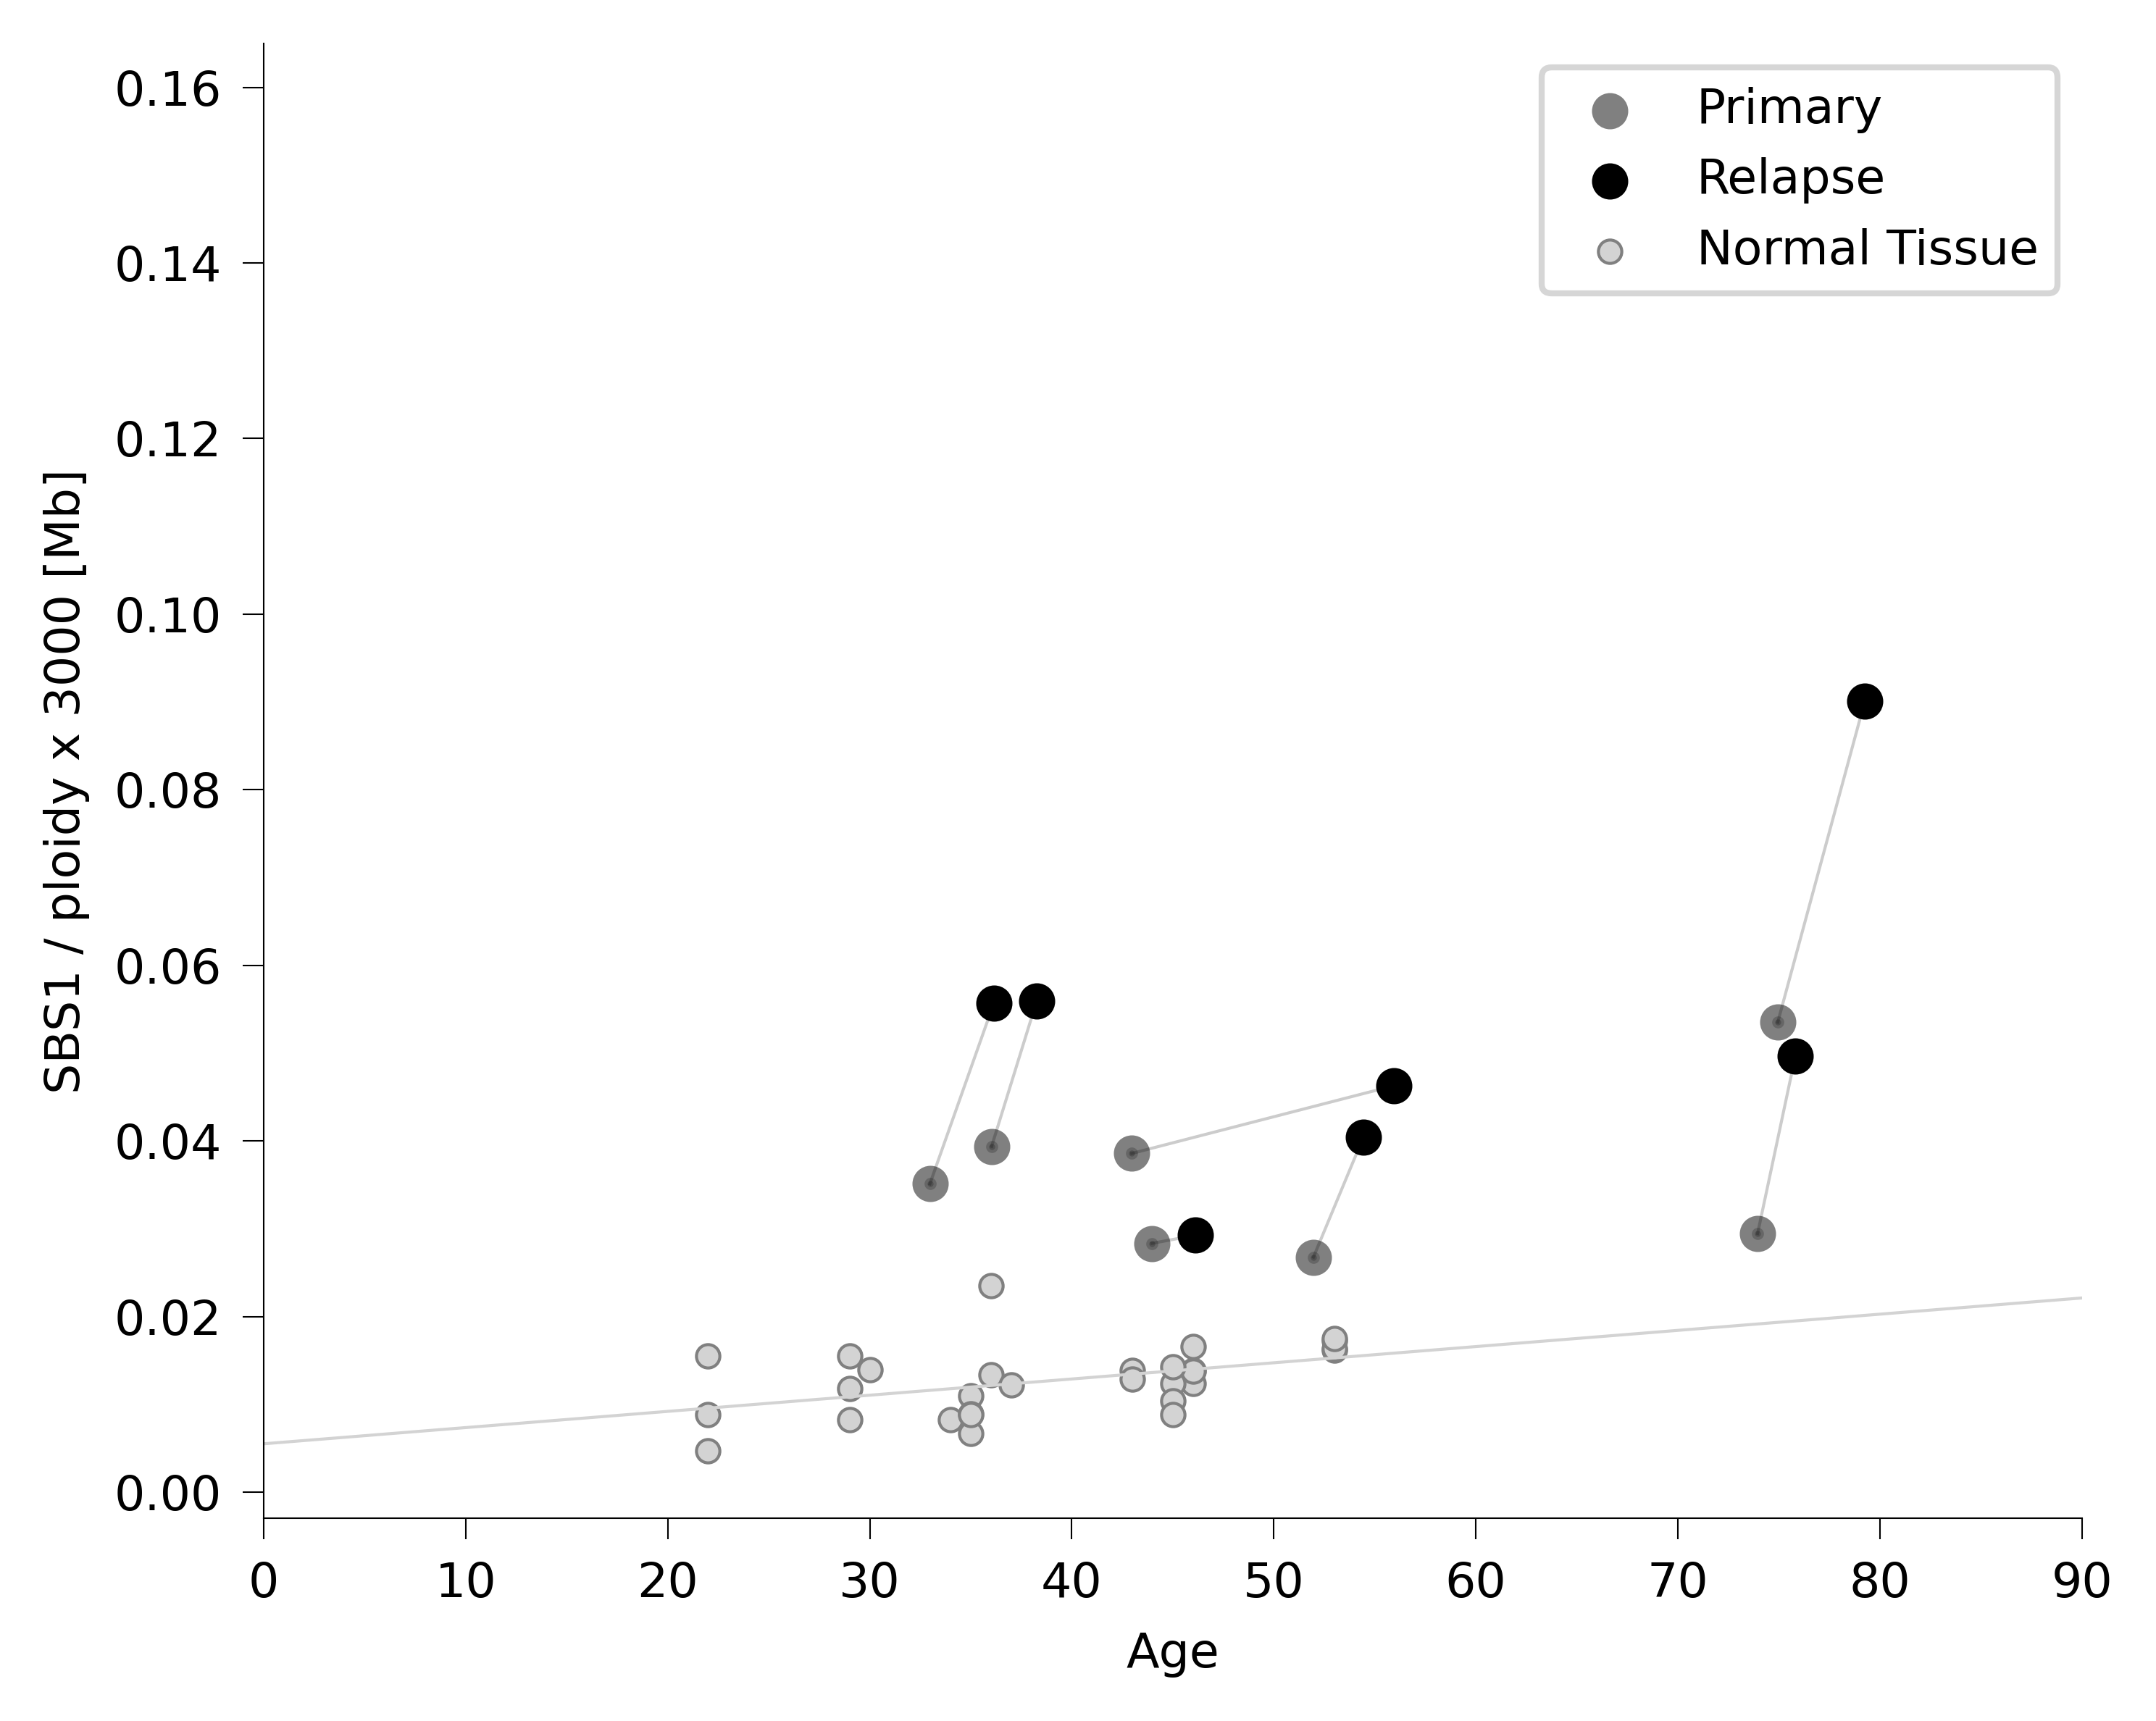

In [9]:
set_mpl_style()
Mets_Metadata = pd.read_excel(S4_METS_XLSX, sheet_name="Fig4C_Sanger").rename(
    columns={"norm_SBS1_prim": "scaled_Prim_SBS1", "norm_SBS1_met": "scaled_Rel_SBS1"})

slope, intercept, *_ = linregress(NormalTissueExposures["age"], NormalTissueExposures["scaled_SBS1"])
x_fit = np.linspace(0, 90, 100); y_fit = slope * x_fit + intercept

fig, ax = plt.subplots(figsize=(5, 4))
for _, r in Mets_Metadata.iterrows():
    ax.plot([r["Primary_age"], r["Relapse age"]], [r["scaled_Prim_SBS1"], r["scaled_Rel_SBS1"]],
            c="k", alpha=0.2, marker="o", markersize=1, linewidth=0.5)
ax.scatter(Mets_Metadata["Primary_age"], Mets_Metadata["scaled_Prim_SBS1"], s=25, color="grey", label="Primary")
ax.scatter(Mets_Metadata["Relapse age"], Mets_Metadata["scaled_Rel_SBS1"], s=25, color="k", label="Relapse")
ax.scatter(NormalTissueExposures["age"], NormalTissueExposures["scaled_SBS1"],
           color="lightgrey", label="Normal Tissue", s=15, edgecolors="grey", linewidths=0.5)
ax.plot(x_fit, y_fit, "-", color="lightgrey", linewidth=0.5)
ax.set_xlabel("Age"); ax.set_ylabel("SBS1 / ploidy x 3000 [Mb]")
ax.set_xlim(0, 90); ax.set_ylim(-0.003, 0.165)
ax.legend(fontsize=8)
for sp in ax.spines.values(): sp.set_linewidth(0.25)
ax.tick_params(width=0.25)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/SBS1_Acceleration_Mets.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [10]:
# SBS1 accumulation rate between primary and relapse (scaled to diploid genome)
def compute_rates_stats(df, scale=2 * 3000, exclude_samples=None):
    if exclude_samples is not None:
        df = df[~df["ID"].isin(exclude_samples)]
    rates = [((r["scaled_Rel_SBS1"] - r["scaled_Prim_SBS1"]) / (r["Relapse age"] - r["Primary_age"])) * scale
             for _, r in df.iterrows() if r["Relapse age"] - r["Primary_age"] > 0]
    rates = np.array(rates)
    print(f"  median={np.median(rates):.2f}  IQR={np.percentile(rates,25):.2f}-{np.percentile(rates,75):.2f}"
          f"  range={rates.min():.2f}-{rates.max():.2f}  n_pairs={len(rates)}")
    return rates

print("=== All metastasis pairs ===");                 _ = compute_rates_stats(Mets_Metadata)
print("=== Excluding PD11461 and PD13596 ===")
_ = compute_rates_stats(Mets_Metadata, exclude_samples=["PD11461", "PD13596"])

=== All metastasis pairs ===
  median=39.02  IQR=18.38-47.72  range=2.58-64.87  n_pairs=7
=== Excluding PD11461 and PD13596 ===
  median=44.52  IQR=39.02-50.92  range=33.19-64.87  n_pairs=5
